# Enhanced SEPA Backtest with EDA Findings

This notebook incorporates findings from `scores_eda.ipynb` and `development_roadmap.md`:

| Finding | Implementation |
|---------|----------------|
| Effective threshold ~0.60 | `min_prob_elite` grid: [0.5, 0.6, 0.65] |
| M03 Trend pillar > 60 beats composite | Gate on `m03_pillar_trend` (not `m03_score`) |
| 5F exposure >= 0.75 is additive | Position scaling via `target_exposure` |
| 3+ consecutive days >= 0.60 | `score_persistence_days` entry rule |
| Score delta IC = 0.166 | `min_score_delta_5d` momentum filter |
| 1d return inverts | Skip T=0 breakout day entries |
| Exit when score < 0.435 | Score decay exit alongside SMA/stop |


In [1]:
import sys
from pathlib import Path

ROOT = Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2


## 1. Data Preparation

Load pre-computed caches with minimal columns to save memory.


In [11]:
# Essential columns for backtest - including OHLC and SMAs from cache
SCORE_COLS = [
    'date', 'ticker',
    # OHLC prices (for exit simulation)
    'open', 'high', 'low', 'close',
    # Pre-computed SMAs (avoid recomputing)
    'sma_20', 'sma_50', 'sma_150', 'sma_200',
    # Model outputs
    'prob_elite', 'calibrated_score', 'normalized_score', 'daily_pct_rank', 'trailing_pct',
    # Entry filters
    'breakout_ok', 'trend_ok',
    # M03 regime (pillar-level for gating)
    'm03_score', 'm03_pillar_trend', 'm03_pillar_liq', 'm03_pillar_risk',
    'm03_delta_5d', 'm03_delta_20d',
    # Forward returns (validation)
    'return_1d', 'return_5d', 'return_20d', 'return_60d',
    # Sector for analysis
    'sector', 'industry',
    # RS for ranking
    'rs_sector_rank', 'rs_industry_rank', 'rs_universe_rank',
]

# Load slim scores cache
scores_path = ROOT / 'notebooks' / 'scores_cache.parquet'
scores_df = pd.read_parquet(scores_path, columns=SCORE_COLS)
scores_df['date'] = pd.to_datetime(scores_df['date'])
print(f"Scores: {len(scores_df):,} rows, {scores_df['ticker'].nunique()} tickers")
print(f"Date range: {scores_df['date'].min().date()} to {scores_df['date'].max().date()}")
print(f"Memory: {scores_df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"OHLC columns: {['open', 'high', 'low', 'close']}")
print(f"SMA columns: {['sma_20', 'sma_50', 'sma_150', 'sma_200']}")


Scores: 4,029,491 rows, 2687 tickers
Date range: 2019-01-02 to 2026-04-30
Memory: 1637.8 MB
OHLC columns: ['open', 'high', 'low', 'close']
SMA columns: ['sma_20', 'sma_50', 'sma_150', 'sma_200']


In [3]:
# Load 5-factor risk model
risk_path = ROOT / 'ideas' / 'risk_5_factor' / 'risk_scores.parquet'
risk_df = pd.read_parquet(risk_path)
risk_df = risk_df.reset_index().rename(columns={'index': 'date'})
risk_df['date'] = pd.to_datetime(risk_df['date'])

# Keep only relevant columns
RISK_COLS = ['date', 'veto_flag', 'target_exposure', 'rolling_percentile', 'weighted_z']
risk_df = risk_df[RISK_COLS].dropna()
print(f"Risk model: {len(risk_df):,} rows")
print(f"Date range: {risk_df['date'].min().date()} to {risk_df['date'].max().date()}")


Risk model: 5,123 rows
Date range: 2005-12-27 to 2026-05-08


In [4]:
# Merge risk data onto scores (daily broadcast)
scores_df = scores_df.merge(risk_df, on='date', how='left')
print(f"Merged: {len(scores_df):,} rows")
print(f"Missing target_exposure: {scores_df['target_exposure'].isna().sum():,}")


Merged: 4,029,491 rows
Missing target_exposure: 0


In [5]:
# Compute score momentum features (for entry timing)
scores_df = scores_df.sort_values(['ticker', 'date'])
scores_df['score_delta_5d'] = scores_df.groupby('ticker')['prob_elite'].diff(5)

# Compute consecutive days above threshold (for persistence rule)
def count_consecutive_above(group, threshold=0.60):
    above = (group['prob_elite'] >= threshold).astype(int)
    cumsum = above.cumsum()
    reset_points = cumsum.where(above == 0).ffill().fillna(0)
    return cumsum - reset_points

scores_df['consec_days_above_060'] = (
    scores_df.groupby('ticker', group_keys=False)
    .apply(count_consecutive_above)
    .astype(int)
)

print(f"Score momentum features added")
print(f"  score_delta_5d range: [{scores_df['score_delta_5d'].min():.3f}, {scores_df['score_delta_5d'].max():.3f}]")
print(f"  consec_days_above_060 max: {scores_df['consec_days_above_060'].max()}")


Score momentum features added
  score_delta_5d range: [-0.375, 0.585]
  consec_days_above_060 max: 80


## 2. Enhanced Vectorized Backtest

Key enhancements:
- M03 pillar-level gating (not composite)
- 5-factor exposure scaling
- Score persistence entry rule
- Score decay exit


In [7]:
from dataclasses import dataclass
from typing import Optional
import quantstats as qs

@dataclass
class BacktestConfig:
    """All backtest parameters in one place."""
    # Date range
    start_date: str = '2020-01-01'
    end_date: str = '2025-01-01'
    warmup_days: int = 10
    
    # Entry: score threshold
    min_prob_elite: float = 0.60
    
    # Entry: M03 regime gate (pillar-level)
    m03_gate: str = 'trend'  # 'none', 'trend', 'trend_liq', 'composite'
    m03_threshold: float = 60.0
    
    # Entry: 5-factor gate
    use_5f_gate: bool = True
    min_5f_exposure: float = 0.75
    
    # Entry: score persistence
    score_persistence_days: int = 0  # 0 = disabled, 3 = require 3+ consecutive days
    
    # Entry: score momentum
    min_score_delta_5d: float = 0.0  # 0 = disabled
    
    # Entry: skip breakout day (1d return inverts)
    skip_breakout_day: bool = False
    
    # Position sizing
    max_positions_per_day: int = 10
    initial_cash: float = 100_000
    position_size_pct: float = 0.10
    use_5f_sizing: bool = False  # Scale position by target_exposure
    
    # Exit: stop loss
    stop_loss_pct: float = 0.15
    
    # Exit: SMA trend
    sma_exit_period: int = 50
    
    # Exit: score decay
    use_score_exit: bool = False
    score_exit_threshold: float = 0.435  # Decile 9 floor
    
    # Exit: max hold
    max_hold_days: int = 252
    
    # Costs
    commission_pct: float = 0.001
    slippage_pct: float = 0.001


In [12]:
def run_enhanced_backtest(
    cfg: BacktestConfig,
    scores: pd.DataFrame,
) -> tuple[pd.DataFrame, dict]:
    """
    Run enhanced vectorized backtest using scores_cache only (no DB).
    
    scores must contain: date, ticker, open, high, low, close, sma_50, sma_200, prob_elite, etc.
    """
    # 1. Filter by date range
    df = scores[
        (scores['date'] >= cfg.start_date) & 
        (scores['date'] <= cfg.end_date)
    ].copy()
    
    # 2. Apply score threshold
    df = df[df['prob_elite'] >= cfg.min_prob_elite]
    
    # 3. Apply M03 regime gate
    if cfg.m03_gate == 'trend':
        df = df[df['m03_pillar_trend'] > cfg.m03_threshold]
    elif cfg.m03_gate == 'trend_liq':
        df = df[
            (df['m03_pillar_trend'] > cfg.m03_threshold) &
            (df['m03_pillar_liq'] > cfg.m03_threshold)
        ]
    elif cfg.m03_gate == 'composite':
        df = df[df['m03_score'] > cfg.m03_threshold]
    
    # 4. Apply 5-factor gate
    if cfg.use_5f_gate and 'target_exposure' in df.columns:
        df = df[df['target_exposure'] >= cfg.min_5f_exposure]
    
    # 5. Apply score persistence
    if cfg.score_persistence_days > 0 and 'consec_days_above_060' in df.columns:
        df = df[df['consec_days_above_060'] >= cfg.score_persistence_days]
    
    # 6. Apply score momentum filter
    if cfg.min_score_delta_5d > 0 and 'score_delta_5d' in df.columns:
        df = df[df['score_delta_5d'] >= cfg.min_score_delta_5d]
    
    # 7. Skip breakout day if configured
    if cfg.skip_breakout_day and 'breakout_ok' in df.columns:
        df['breakout_yesterday'] = df.groupby('ticker')['breakout_ok'].shift(1)
        df = df[df['breakout_yesterday'] == True]
        df = df.drop(columns=['breakout_yesterday'])
    
    # 8. Apply warmup
    unique_dates = pd.Series(df['date'].unique()).sort_values().reset_index(drop=True)
    if len(unique_dates) <= cfg.warmup_days:
        return pd.DataFrame(), {'n_trades': 0, 'error': 'insufficient_dates'}
    warmup_cutoff = unique_dates.iloc[cfg.warmup_days]
    df = df[df['date'] >= warmup_cutoff]
    
    # 9. Rank and select top N per day
    df['daily_rank'] = df.groupby('date')['prob_elite'].rank(ascending=False, method='first')
    df = df[df['daily_rank'] <= cfg.max_positions_per_day]
    
    # 10. Deduplicate: first entry per ticker
    df = df.sort_values(['ticker', 'date'])
    entries = df.drop_duplicates(subset=['ticker'], keep='first')
    
    if entries.empty:
        return pd.DataFrame(), {'n_trades': 0, 'error': 'no_entries'}
    
    # Select SMA column based on config
    sma_col_map = {20: 'sma_20', 50: 'sma_50', 100: 'sma_50', 150: 'sma_150', 200: 'sma_200'}
    sma_col = sma_col_map.get(cfg.sma_exit_period, 'sma_50')
    
    # Build entry records
    entry_cols = ['ticker', 'date', 'close', 'prob_elite', 'calibrated_score']
    if 'target_exposure' in entries.columns:
        entry_cols.append('target_exposure')
    entry_prices = entries[entry_cols].rename(
        columns={'date': 'entry_date', 'close': 'entry_price', 'prob_elite': 'prob_elite_at_entry'}
    )
    
    # Get full price history for entered tickers only
    entered_tickers = entries['ticker'].unique()
    prices = scores[scores['ticker'].isin(entered_tickers)][
        ['date', 'ticker', 'open', 'high', 'low', 'close', sma_col, 'prob_elite']
    ].copy()
    prices = prices.rename(columns={sma_col: 'sma', 'prob_elite': 'current_score'})
    prices = prices.sort_values(['ticker', 'date'])
    
    # Merge for exit simulation
    merge_cols = ['ticker', 'entry_date', 'entry_price', 'prob_elite_at_entry']
    if 'target_exposure' in entry_prices.columns:
        merge_cols.append('target_exposure')
    merged = prices.merge(entry_prices[merge_cols], on='ticker', how='inner')
    merged = merged[merged['date'] > merged['entry_date']].copy()
    
    if merged.empty:
        return pd.DataFrame(), {'n_trades': 0, 'error': 'no_post_entry_bars'}
    
    # Exit conditions
    merged['stop_level'] = merged['entry_price'] * (1.0 - cfg.stop_loss_pct)
    merged['hit_stop'] = merged['low'] <= merged['stop_level']
    merged['hit_trend'] = merged['close'] < merged['sma']
    merged['bars_held'] = merged.groupby(['ticker', 'entry_date']).cumcount() + 1
    merged['hit_timeout'] = merged['bars_held'] >= cfg.max_hold_days
    
    if cfg.use_score_exit:
        merged['hit_score_decay'] = merged['current_score'] < cfg.score_exit_threshold
    else:
        merged['hit_score_decay'] = False
    
    conditions = [merged['hit_stop'], merged['hit_score_decay'], merged['hit_trend'], merged['hit_timeout']]
    choices = ['stop_loss', 'score_decay', 'trend_break', 'max_hold']
    merged['exit_candidate'] = np.select(conditions, choices, default='')
    
    exits = merged[merged['exit_candidate'] != ''].copy()
    first_exits = exits.sort_values(['ticker', 'entry_date', 'date']).drop_duplicates(
        subset=['ticker', 'entry_date'], keep='first'
    )
    
    first_exits['exit_price'] = np.where(
        first_exits['exit_candidate'] == 'stop_loss',
        first_exits['stop_level'],
        first_exits['close'],
    )
    
    trades = entry_prices.merge(
        first_exits[['ticker', 'entry_date', 'date', 'exit_price', 'exit_candidate']],
        on=['ticker', 'entry_date'],
        how='left',
    ).rename(columns={'date': 'exit_date', 'exit_candidate': 'exit_reason'})
    
    # Mark open positions
    open_mask = trades['exit_date'].isna()
    if open_mask.any():
        last_prices = (
            prices.sort_values(['ticker', 'date'])
            .groupby('ticker').tail(1)[['ticker', 'date', 'close']]
            .rename(columns={'date': 'last_date', 'close': 'last_close'})
        )
        trades = trades.merge(last_prices, on='ticker', how='left')
        trades.loc[open_mask, 'exit_date'] = trades.loc[open_mask, 'last_date']
        trades.loc[open_mask, 'exit_price'] = trades.loc[open_mask, 'last_close']
        trades.loc[open_mask, 'exit_reason'] = 'held_open'
        trades = trades.drop(columns=['last_date', 'last_close'], errors='ignore')
    
    # Compute PnL
    trades['pnl_pct'] = (trades['exit_price'] - trades['entry_price']) / trades['entry_price']
    trades['holding_days'] = (pd.to_datetime(trades['exit_date']) - pd.to_datetime(trades['entry_date'])).dt.days
    
    # Apply costs
    cost = 2 * (cfg.commission_pct + cfg.slippage_pct)
    trades['pnl_pct'] = trades['pnl_pct'] - cost
    
    # Position sizing
    if cfg.use_5f_sizing and 'target_exposure' in trades.columns:
        trades['position_size'] = cfg.position_size_pct * trades['target_exposure'].fillna(1.0)
    else:
        trades['position_size'] = cfg.position_size_pct
    
    # Stats
    if len(trades) == 0:
        return trades, {'n_trades': 0}
    
    wins = trades[trades['pnl_pct'] > 0]
    losses = trades[trades['pnl_pct'] <= 0]
    pf = abs(wins['pnl_pct'].sum() / losses['pnl_pct'].sum()) if len(losses) and losses['pnl_pct'].sum() != 0 else float('inf')
    
    # Equity curve
    returns_by_date = {}
    for _, t in trades.iterrows():
        exit_d = pd.Timestamp(t['exit_date'])
        pnl_dollar = cfg.initial_cash * t['position_size'] * t['pnl_pct']
        returns_by_date[exit_d] = returns_by_date.get(exit_d, 0.0) + pnl_dollar
    
    dates = pd.date_range(
        start=pd.Timestamp(trades['entry_date'].min()),
        end=pd.Timestamp(trades['exit_date'].max()),
        freq='B',
    )
    daily_pnl = pd.Series(0.0, index=dates)
    for d, v in returns_by_date.items():
        if d in daily_pnl.index:
            daily_pnl.loc[d] += v
        else:
            nearest = daily_pnl.index[daily_pnl.index >= d]
            if len(nearest):
                daily_pnl.loc[nearest[0]] += v
    equity = cfg.initial_cash + daily_pnl.cumsum()
    returns = equity.pct_change().dropna()
    
    total_ret = (equity.iloc[-1] - equity.iloc[0]) / equity.iloc[0] * 100 if len(equity) > 1 else 0
    sharpe = qs.stats.sharpe(returns) if len(returns) > 10 else 0
    max_dd = qs.stats.max_drawdown(returns) * 100 if len(returns) > 10 else 0
    
    stats = {
        'n_trades': len(trades),
        'n_tickers': trades['ticker'].nunique(),
        'win_rate': len(wins) / len(trades),
        'avg_pnl': trades['pnl_pct'].mean(),
        'median_pnl': trades['pnl_pct'].median(),
        'profit_factor': pf,
        'total_return': total_ret,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'avg_hold_days': trades['holding_days'].mean(),
        'exit_reasons': trades['exit_reason'].value_counts().to_dict(),
    }
    
    return trades, stats


## 3. Baseline vs Enhanced


In [13]:
# Baseline: original parameters (no regime gating)
cfg_baseline = BacktestConfig(
    start_date='2020-01-01',
    end_date='2025-01-01',
    min_prob_elite=0.50,
    m03_gate='none',
    use_5f_gate=False,
    stop_loss_pct=0.15,
    sma_exit_period=50,
    max_positions_per_day=10,
)

trades_baseline, stats_baseline = run_enhanced_backtest(cfg_baseline, scores_df)
print("BASELINE (no regime gating):")
for k, v in stats_baseline.items():
    if k == 'exit_reasons':
        print(f"  {k}: {v}")
    elif isinstance(v, float):
        print(f"  {k}: {v:.3f}")
    else:
        print(f"  {k}: {v}")


BASELINE (no regime gating):
  n_trades: 614
  n_tickers: 614
  win_rate: 0.331
  avg_pnl: 0.082
  median_pnl: -0.134
  profit_factor: 1.925
  total_return: 505.427
  sharpe: 0.437
  max_dd: -108.342
  avg_hold_days: 43.739
  exit_reasons: {'trend_break': 317, 'stop_loss': 297}


In [14]:
# Enhanced: with EDA findings
cfg_enhanced = BacktestConfig(
    start_date='2020-01-01',
    end_date='2025-01-01',
    min_prob_elite=0.60,
    m03_gate='trend',
    m03_threshold=60.0,
    use_5f_gate=True,
    min_5f_exposure=0.75,
    score_persistence_days=3,
    stop_loss_pct=0.15,
    sma_exit_period=100,
    max_positions_per_day=10,
)

trades_enhanced, stats_enhanced = run_enhanced_backtest(cfg_enhanced, scores_df)
print("\nENHANCED (with EDA findings):")
for k, v in stats_enhanced.items():
    if k == 'exit_reasons':
        print(f"  {k}: {v}")
    elif isinstance(v, float):
        print(f"  {k}: {v:.3f}")
    else:
        print(f"  {k}: {v}")



ENHANCED (with EDA findings):
  n_trades: 489
  n_tickers: 489
  win_rate: 0.335
  avg_pnl: 0.084
  median_pnl: -0.154
  profit_factor: 1.930
  total_return: 411.010
  sharpe: 0.673
  max_dd: -92.814
  avg_hold_days: 43.620
  exit_reasons: {'stop_loss': 250, 'trend_break': 239}


In [15]:
print(f"\n{'='*60}")
print("COMPARISON: Baseline vs Enhanced")
print(f"{'='*60}")
print(f"{'Metric':<20} {'Baseline':<15} {'Enhanced':<15} {'Delta':<15}")
print(f"{'-'*60}")
for key in ['n_trades', 'win_rate', 'avg_pnl', 'profit_factor', 'total_return', 'sharpe', 'max_dd']:
    b = stats_baseline.get(key, 0)
    e = stats_enhanced.get(key, 0)
    if isinstance(b, float):
        delta = e - b
        print(f"{key:<20} {b:<15.3f} {e:<15.3f} {delta:+.3f}")
    else:
        print(f"{key:<20} {b:<15} {e:<15}")



COMPARISON: Baseline vs Enhanced
Metric               Baseline        Enhanced        Delta          
------------------------------------------------------------
n_trades             614             489            
win_rate             0.331           0.335           +0.005
avg_pnl              0.082           0.084           +0.002
profit_factor        1.925           1.930           +0.005
total_return         505.427         411.010         -94.417
sharpe               0.437           0.673           +0.237
max_dd               -108.342        -92.814         +15.528


## 4. Parameter Sweep


### Vectorised Sweep

In [16]:
import itertools
from tqdm.auto import tqdm

GRID = {
    'min_prob_elite': [0.43, 0.60, 0.7],
    'm03_gate': ['none', 'trend', 'trend_liq'],
    'use_5f_gate': [False, True],
    'score_persistence_days': [0, 3],
    'stop_loss_pct': [0.10, 0.15, 0.20],
    'sma_exit_period': [50, 100],
}

FIXED = dict(
    start_date='2020-01-01',
    end_date='2025-01-01',
    m03_threshold=60.0,
    min_5f_exposure=0.75,
    max_positions_per_day=10,
    initial_cash=100_000,
    position_size_pct=0.10,
)

keys = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f"Running {len(combos)} parameter combinations...")


Running 216 parameter combinations...


In [17]:
results = []

for combo in tqdm(combos, desc="Sweep"):
    params = dict(zip(keys, combo))
    cfg = BacktestConfig(**FIXED, **params)
    
    try:
        trades, stats = run_enhanced_backtest(cfg, scores_df)
        row = {**params, **{k: stats.get(k, 0) for k in ['n_trades', 'win_rate', 'avg_pnl', 'profit_factor', 'total_return', 'sharpe', 'max_dd']}}
    except Exception as e:
        row = {**params, 'n_trades': 0, 'win_rate': 0, 'avg_pnl': 0, 'profit_factor': 0, 'total_return': 0, 'sharpe': 0, 'max_dd': 0, 'error': str(e)}
    results.append(row)

results_df = pd.DataFrame(results)


Sweep:   0%|          | 0/216 [00:00<?, ?it/s]

In [19]:
valid = results_df[results_df['n_trades'] >= 20].sort_values('sharpe', ascending=False)

print(f"\n{'='*100}")
print(f"TOP 20 COMBINATIONS (by Sharpe, min 20 trades)")
print(f"{'='*100}")

display(valid.head(20).style.format({
    'win_rate': '{:.1%}', 'avg_pnl': '{:+.2%}', 'profit_factor': '{:.2f}',
    'total_return': '{:+.1f}%', 'sharpe': '{:.2f}', 'max_dd': '{:.1f}%',
}))



TOP 20 COMBINATIONS (by Sharpe, min 20 trades)


,min_prob_elite,m03_gate,use_5f_gate,score_persistence_days,stop_loss_pct,sma_exit_period,n_trades,win_rate,avg_pnl,profit_factor,total_return,sharpe,max_dd
154,0.700000,none,False,3,0.200000,50,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
161,0.700000,none,True,0,0.200000,100,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
160,0.700000,none,True,0,0.200000,50,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
166,0.700000,none,True,3,0.200000,50,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
167,0.700000,none,True,3,0.200000,100,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
148,0.700000,none,False,0,0.200000,50,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
149,0.700000,none,False,0,0.200000,100,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
155,0.700000,none,False,3,0.200000,100,155,56.1%,+32.87%,5.39,+509.5%,1.56,-14.3%
184,0.700000,trend,True,0,0.200000,50,148,56.1%,+34.50%,5.70,+510.5%,1.55,-15.1%
191,0.700000,trend,True,3,0.200000,100,148,56.1%,+34.50%,5.70,+510.5%,1.55,-15.1%


In [20]:
print("\nAVERAGE SHARPE BY PARAMETER:")
print("="*40)

for param in keys:
    print(f"\n{param}:")
    agg = valid.groupby(param)['sharpe'].agg(['mean', 'std', 'count'])
    for val, row in agg.iterrows():
        print(f"  {val}: {row['mean']:.3f} +/- {row['std']:.3f} (n={int(row['count'])})")



AVERAGE SHARPE BY PARAMETER:

min_prob_elite:
  0.43: 0.548 +/- 0.260 (n=72)
  0.6: 0.554 +/- 0.314 (n=72)
  0.7: 1.210 +/- 0.228 (n=72)

m03_gate:
  none: 0.701 +/- 0.517 (n=72)
  trend: 0.782 +/- 0.468 (n=72)
  trend_liq: 0.829 +/- 0.129 (n=72)

use_5f_gate:
  False: 0.771 +/- 0.412 (n=108)
  True: 0.771 +/- 0.412 (n=108)

score_persistence_days:
  0: 0.771 +/- 0.412 (n=108)
  3: 0.771 +/- 0.412 (n=108)

stop_loss_pct:
  0.1: 0.825 +/- 0.202 (n=72)
  0.15: 0.668 +/- 0.463 (n=72)
  0.2: 0.819 +/- 0.490 (n=72)

sma_exit_period:
  50: 0.771 +/- 0.412 (n=108)
  100: 0.771 +/- 0.412 (n=108)


In [21]:
if len(valid) > 0:
    best_row = valid.iloc[0]
    best_params = {k: best_row[k] for k in keys}
    print("BEST CONFIG:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    print(f"\n  Sharpe: {best_row['sharpe']:.2f}")
    print(f"  Total Return: {best_row['total_return']:.1f}%")
    print(f"  Win Rate: {best_row['win_rate']:.1%}")
    print(f"  Profit Factor: {best_row['profit_factor']:.2f}")


BEST CONFIG:
  min_prob_elite: 0.7
  m03_gate: none
  use_5f_gate: False
  score_persistence_days: 3
  stop_loss_pct: 0.2
  sma_exit_period: 50

  Sharpe: 1.56
  Total Return: 509.5%
  Win Rate: 56.1%
  Profit Factor: 5.39


### Examine best config

In [24]:
# ============================================================
# BACKTEST HELPER (Cache-based, Sequential Execution)
# ============================================================
from dataclasses import dataclass, field
from typing import Optional
import pandas as pd
import numpy as np
import quantstats as qs

@dataclass
class BacktestConfig:
    """All backtest parameters in one place."""
    # Date range
    start_date: str = '2020-01-01'
    end_date: str = '2025-01-01'
    warmup_days: int = 10
    
    # Entry: score threshold
    min_prob_elite: float = 0.60
    
    # Entry: M03 regime gate (pillar-level)
    m03_gate: str = 'trend'  # 'none', 'trend', 'trend_liq', 'composite'
    m03_threshold: float = 60.0
    
    # Entry: 5-factor gate
    use_5f_gate: bool = True
    min_5f_exposure: float = 0.75
    
    # Entry: score persistence
    score_persistence_days: int = 0  # 0 = disabled, 3 = require 3+ consecutive days
    
    # Entry: score momentum
    min_score_delta_5d: float = 0.0  # 0 = disabled
    
    # Entry: skip breakout day (1d return inverts)
    skip_breakout_day: bool = False
    
    # Entry: cooldown (days before re-entry same ticker)
    cooldown_days: int = 20
    
    # Position sizing
    max_positions: int = 10  # Max concurrent open positions
    initial_cash: float = 100_000
    position_size_pct: float = 0.10
    use_5f_sizing: bool = False
    
    # Exit: stop loss
    stop_loss_pct: float = 0.15
    
    # Exit: SMA trend (20, 50, 150, 200 available in cache)
    sma_exit_period: int = 50
    
    # Exit: score decay
    use_score_exit: bool = False
    score_exit_threshold: float = 0.435
    
    # Exit: max hold
    max_hold_days: int = 252
    
    # Costs
    commission_pct: float = 0.001
    slippage_pct: float = 0.001


@dataclass
class Position:
    """Track an open position."""
    ticker: str
    entry_date: pd.Timestamp
    entry_price: float
    stop_level: float
    shares: float
    prob_elite_at_entry: float
    target_exposure: float = 1.0


def run_backtest(
    cfg: BacktestConfig,
    scores_df: pd.DataFrame,
    verbose: bool = True,
) -> tuple[pd.DataFrame, dict, pd.Series]:
    """
    Run sequential day-by-day backtest with realistic capital management.
    
    Args:
        cfg: BacktestConfig with all parameters
        scores_df: Pre-loaded DataFrame with OHLC, SMAs, prob_elite, M03, etc.
        verbose: Print progress and summary
    
    Returns:
        trades: DataFrame with trade-level results
        stats: Summary statistics dict
        equity: Daily equity curve Series
    """
    # === SETUP ===
    df = scores_df[
        (scores_df['date'] >= cfg.start_date) & 
        (scores_df['date'] <= cfg.end_date)
    ].copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values(['date', 'ticker'])
    
    # Map SMA period to available column
    sma_col_map = {20: 'sma_20', 50: 'sma_50', 150: 'sma_150', 200: 'sma_200'}
    sma_col = sma_col_map.get(cfg.sma_exit_period, 'sma_50')
    
    # Get trading days
    trading_days = sorted(df['date'].unique())
    if len(trading_days) <= cfg.warmup_days:
        return pd.DataFrame(), {'n_trades': 0, 'error': 'insufficient_dates'}, pd.Series()
    
    # Skip warmup
    trading_days = trading_days[cfg.warmup_days:]
    
    # === STATE ===
    cash = cfg.initial_cash
    positions: dict[str, Position] = {}  # ticker -> Position
    trades: list[dict] = []
    equity_curve: dict[pd.Timestamp, float] = {}
    last_exit: dict[str, pd.Timestamp] = {}  # ticker -> last exit date (for cooldown)
    
    # === DAY-BY-DAY LOOP ===
    for day in trading_days:
        day_data = df[df['date'] == day].set_index('ticker')
        
        # --- 1. CHECK EXITS FOR OPEN POSITIONS ---
        closed_tickers = []
        for ticker, pos in list(positions.items()):
            if ticker not in day_data.index:
                continue  # No data for this ticker today
            
            bar = day_data.loc[ticker]
            bars_held = (day - pos.entry_date).days
            
            # Exit conditions (priority order)
            exit_reason = None
            exit_price = None
            
            # Stop loss (intraday)
            if bar['low'] <= pos.stop_level:
                exit_reason = 'stop_loss'
                exit_price = pos.stop_level
            
            # Score decay
            elif cfg.use_score_exit and bar['prob_elite'] < cfg.score_exit_threshold:
                exit_reason = 'score_decay'
                exit_price = bar['close']
            
            # Trend break (close below SMA)
            elif bar['close'] < bar[sma_col]:
                exit_reason = 'trend_break'
                exit_price = bar['close']
            
            # Max hold timeout
            elif bars_held >= cfg.max_hold_days:
                exit_reason = 'max_hold'
                exit_price = bar['close']
            
            if exit_reason:
                # Record trade
                pnl_pct = (exit_price - pos.entry_price) / pos.entry_price
                pnl_pct -= 2 * (cfg.commission_pct + cfg.slippage_pct)  # Round-trip cost
                pnl_dollar = pos.shares * pos.entry_price * pnl_pct
                
                trades.append({
                    'ticker': ticker,
                    'entry_date': pos.entry_date,
                    'entry_price': pos.entry_price,
                    'exit_date': day,
                    'exit_price': exit_price,
                    'exit_reason': exit_reason,
                    'pnl_pct': pnl_pct,
                    'pnl_dollar': pnl_dollar,
                    'holding_days': bars_held,
                    'prob_elite_at_entry': pos.prob_elite_at_entry,
                })
                
                # Return capital
                cash += pos.shares * exit_price
                closed_tickers.append(ticker)
                last_exit[ticker] = day
        
        # Remove closed positions
        for ticker in closed_tickers:
            del positions[ticker]
        
        # --- 2. FIND NEW ENTRY CANDIDATES ---
        available_slots = cfg.max_positions - len(positions)
        
        if available_slots > 0:
            candidates = day_data.copy()
            
            # Apply filters
            candidates = candidates[candidates['prob_elite'] >= cfg.min_prob_elite]
            
            # M03 gate
            if cfg.m03_gate == 'trend':
                candidates = candidates[candidates['m03_pillar_trend'] > cfg.m03_threshold]
            elif cfg.m03_gate == 'trend_liq':
                candidates = candidates[
                    (candidates['m03_pillar_trend'] > cfg.m03_threshold) &
                    (candidates['m03_pillar_liq'] > cfg.m03_threshold)
                ]
            elif cfg.m03_gate == 'composite':
                candidates = candidates[candidates['m03_score'] > cfg.m03_threshold]
            
            # 5-factor gate
            if cfg.use_5f_gate and 'target_exposure' in candidates.columns:
                candidates = candidates[candidates['target_exposure'] >= cfg.min_5f_exposure]
            
            # Score persistence
            if cfg.score_persistence_days > 0 and 'consec_days_above_060' in candidates.columns:
                candidates = candidates[candidates['consec_days_above_060'] >= cfg.score_persistence_days]
            
            # Score momentum
            if cfg.min_score_delta_5d > 0 and 'score_delta_5d' in candidates.columns:
                candidates = candidates[candidates['score_delta_5d'] >= cfg.min_score_delta_5d]
            
            # Skip already held tickers
            candidates = candidates[~candidates.index.isin(positions.keys())]
            
            # Skip tickers in cooldown
            if cfg.cooldown_days > 0:
                cooldown_mask = candidates.index.map(
                    lambda t: t not in last_exit or (day - last_exit[t]).days >= cfg.cooldown_days
                )
                candidates = candidates[cooldown_mask]
            
            # Rank by prob_elite, take top N
            if len(candidates) > 0:
                candidates = candidates.sort_values('prob_elite', ascending=False)
                candidates = candidates.head(available_slots)
                
                # Enter positions
                for ticker in candidates.index:
                    bar = candidates.loc[ticker]
                    
                    # Position sizing
                    if cfg.use_5f_sizing and 'target_exposure' in bar.index:
                        size_pct = cfg.position_size_pct * bar.get('target_exposure', 1.0)
                    else:
                        size_pct = cfg.position_size_pct
                    
                    position_value = cash * size_pct  # Size based on current cash
                    if position_value < 100:  # Min position size
                        continue
                    
                    entry_price = bar['close']
                    shares = position_value / entry_price
                    
                    positions[ticker] = Position(
                        ticker=ticker,
                        entry_date=day,
                        entry_price=entry_price,
                        stop_level=entry_price * (1 - cfg.stop_loss_pct),
                        shares=shares,
                        prob_elite_at_entry=bar['prob_elite'],
                        target_exposure=bar.get('target_exposure', 1.0) if 'target_exposure' in bar.index else 1.0,
                    )
                    
                    # Deduct cash (including entry cost)
                    cash -= shares * entry_price * (1 + cfg.commission_pct + cfg.slippage_pct)
        
        # --- 3. RECORD DAILY EQUITY ---
        # Cash + mark-to-market value of open positions
        portfolio_value = cash
        for ticker, pos in positions.items():
            if ticker in day_data.index:
                portfolio_value += pos.shares * day_data.loc[ticker, 'close']
            else:
                # Use last known price (position value unchanged)
                portfolio_value += pos.shares * pos.entry_price
        
        equity_curve[day] = portfolio_value
    
    # === CLOSE REMAINING POSITIONS (mark-to-market) ===
    final_day = trading_days[-1]
    final_data = df[df['date'] == final_day].set_index('ticker')
    
    for ticker, pos in positions.items():
        if ticker in final_data.index:
            exit_price = final_data.loc[ticker, 'close']
        else:
            exit_price = pos.entry_price  # No data, use entry price
        
        bars_held = (final_day - pos.entry_date).days
        pnl_pct = (exit_price - pos.entry_price) / pos.entry_price
        pnl_pct -= 2 * (cfg.commission_pct + cfg.slippage_pct)
        pnl_dollar = pos.shares * pos.entry_price * pnl_pct
        
        trades.append({
            'ticker': ticker,
            'entry_date': pos.entry_date,
            'entry_price': pos.entry_price,
            'exit_date': final_day,
            'exit_price': exit_price,
            'exit_reason': 'held_open',
            'pnl_pct': pnl_pct,
            'pnl_dollar': pnl_dollar,
            'holding_days': bars_held,
            'prob_elite_at_entry': pos.prob_elite_at_entry,
        })
    
    # === BUILD RESULTS ===
    trades_df = pd.DataFrame(trades)
    equity = pd.Series(equity_curve).sort_index()
    
    if len(trades_df) == 0:
        return trades_df, {'n_trades': 0}, equity
    
    # Stats
    wins = trades_df[trades_df['pnl_pct'] > 0]
    losses = trades_df[trades_df['pnl_pct'] <= 0]
    pf = abs(wins['pnl_pct'].sum() / losses['pnl_pct'].sum()) if len(losses) and losses['pnl_pct'].sum() != 0 else float('inf')
    
    returns = equity.pct_change().dropna()
    total_ret = (equity.iloc[-1] - equity.iloc[0]) / equity.iloc[0] * 100 if len(equity) > 1 else 0
    sharpe = qs.stats.sharpe(returns) if len(returns) > 10 else 0
    max_dd = qs.stats.max_drawdown(returns) * 100 if len(returns) > 10 else 0
    cagr = qs.stats.cagr(returns) * 100 if len(returns) > 10 else 0
    
    stats = {
        'n_trades': len(trades_df),
        'n_tickers': trades_df['ticker'].nunique(),
        'win_rate': len(wins) / len(trades_df),
        'avg_pnl': trades_df['pnl_pct'].mean(),
        'median_pnl': trades_df['pnl_pct'].median(),
        'profit_factor': pf,
        'total_return': total_ret,
        'cagr': cagr,
        'sharpe': sharpe,
        'max_dd': max_dd,
        'avg_hold_days': trades_df['holding_days'].mean(),
        'exit_reasons': trades_df['exit_reason'].value_counts().to_dict(),
        'total_pnl_dollar': trades_df['pnl_dollar'].sum(),
        'final_equity': equity.iloc[-1],
    }
    
    if verbose:
        print(f"\n{'='*60}")
        print(f"BACKTEST: {cfg.start_date} → {cfg.end_date}")
        print(f"{'='*60}")
        print(f"  Trades:         {stats['n_trades']}")
        print(f"  Unique Tickers: {stats['n_tickers']}")
        print(f"  Win Rate:       {stats['win_rate']:.1%}")
        print(f"  Avg PnL:        {stats['avg_pnl']:+.2%}")
        print(f"  Median PnL:     {stats['median_pnl']:+.2%}")
        print(f"  Profit Factor:  {stats['profit_factor']:.2f}")
        print(f"  Total Return:   {stats['total_return']:+.1f}%")
        print(f"  CAGR:           {stats['cagr']:+.1f}%")
        print(f"  Sharpe:         {stats['sharpe']:.2f}")
        print(f"  Max Drawdown:   {stats['max_dd']:.1f}%")
        print(f"  Avg Hold:       {stats['avg_hold_days']:.1f} days")
        print(f"  Final Equity:   ${stats['final_equity']:,.0f}")
        print(f"  Exit Reasons:   {stats['exit_reasons']}")
    
    return trades_df, stats, equity



BACKTEST: 2020-01-01 → 2025-01-01
  Trades:         118
  Unique Tickers: 76
  Win Rate:       37.3%
  Avg PnL:        +7.81%
  Median PnL:     -12.96%
  Profit Factor:  1.72
  Total Return:   +55.6%
  CAGR:           +9.3%
  Sharpe:         0.55
  Max Drawdown:   -35.7%
  Avg Hold:       46.4 days
  Final Equity:   $155,569
  Exit Reasons:   {'trend_break': 62, 'stop_loss': 51, 'held_open': 5}


<Axes: title={'center': 'Portfolio Equity'}>

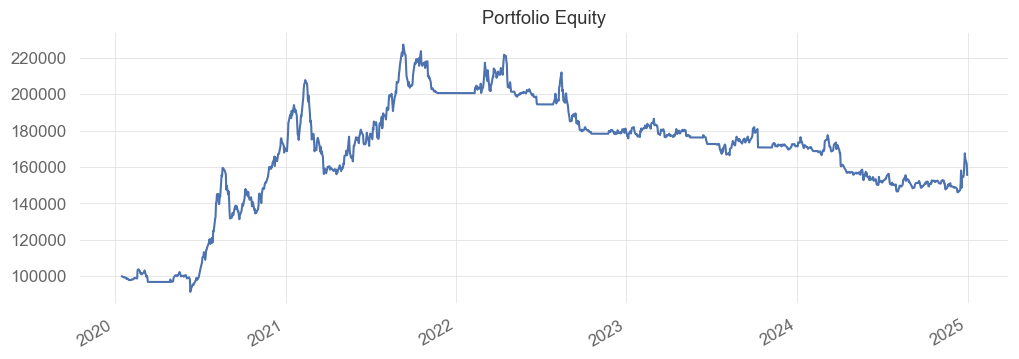

In [27]:
cfg = BacktestConfig(
    start_date='2020-01-01',
    end_date='2025-01-01',
    min_prob_elite=0.70,
    m03_gate='none',
    use_5f_gate=False,
    score_persistence_days=3,
    stop_loss_pct=0.20,
    sma_exit_period=50
)

trades, stats, equity = run_backtest(cfg, scores_df)

# Plot equity curve
equity.plot(title='Portfolio Equity', figsize=(12, 4))


### Sequential Sweep

In [ ]:
# ============================================================
# SEQUENTIAL PARAMETER SWEEP (Realistic)
# ============================================================
import itertools
from tqdm.auto import tqdm

# Reduced grid - focus on parameters that matter most
GRID = {
    'min_prob_elite': [0.43, 0.70],
    'm03_gate': ['none', 'trend'],
    'score_persistence_days': [0, 3],
    'stop_loss_pct': [0.15, 0.20],
    'sma_exit_period': [100],
}

# Fixed params
FIXED = dict(
    start_date='2020-01-01',
    end_date='2025-01-01',
    m03_threshold=60.0,
    use_5f_gate=False,  # Simplify for now
    max_positions=10,
    initial_cash=100_000,
    position_size_pct=0.10,
    cooldown_days=20,
    warmup_days=10,
)

keys = list(GRID.keys())
combos = list(itertools.product(*GRID.values()))
print(f"Running {len(combos)} parameter combinations (sequential backtest)...")

Running 16 parameter combinations (sequential backtest)...


In [29]:
results = []

for combo in tqdm(combos, desc="Sequential Sweep"):
    params = dict(zip(keys, combo))
    cfg = BacktestConfig(**FIXED, **params)
    
    try:
        trades, stats, equity = run_backtest(cfg, scores_df, verbose=False)
        row = {
            **params,
            'n_trades': stats.get('n_trades', 0),
            'win_rate': stats.get('win_rate', 0),
            'avg_pnl': stats.get('avg_pnl', 0),
            'profit_factor': stats.get('profit_factor', 0),
            'total_return': stats.get('total_return', 0),
            'cagr': stats.get('cagr', 0),
            'sharpe': stats.get('sharpe', 0),
            'max_dd': stats.get('max_dd', 0),
            'avg_hold_days': stats.get('avg_hold_days', 0),
        }
    except Exception as e:
        row = {**params, 'n_trades': 0, 'sharpe': 0, 'error': str(e)}
    results.append(row)

results_df = pd.DataFrame(results)


Sequential Sweep:   0%|          | 0/16 [00:00<?, ?it/s]

In [30]:
# Filter and sort
valid = results_df[results_df['n_trades'] >= 30].sort_values('sharpe', ascending=False)

print(f"\n{'='*120}")
print(f"TOP 15 CONFIGS (Sequential Backtest, min 30 trades)")
print(f"{'='*120}")

display(valid.head(15).style.format({
    'win_rate': '{:.1%}',
    'avg_pnl': '{:+.2%}',
    'profit_factor': '{:.2f}',
    'total_return': '{:+.1f}%',
    'cagr': '{:+.1f}%',
    'sharpe': '{:.2f}',
    'max_dd': '{:.1f}%',
    'avg_hold_days': '{:.0f}',
}))



TOP 15 CONFIGS (Sequential Backtest, min 30 trades)


,min_prob_elite,m03_gate,score_persistence_days,stop_loss_pct,sma_exit_period,n_trades,win_rate,avg_pnl,profit_factor,total_return,cagr,sharpe,max_dd,avg_hold_days
1,0.430000,none,0,0.200000,100,495,38.4%,+4.26%,1.49,+187.5%,+23.8%,0.83,-33.5%,37
3,0.430000,none,3,0.200000,100,495,38.4%,+4.26%,1.49,+187.5%,+23.8%,0.83,-33.5%,37
0,0.430000,none,0,0.150000,100,595,35.1%,+3.91%,1.48,+177.2%,+22.9%,0.80,-29.0%,30
2,0.430000,none,3,0.150000,100,595,35.1%,+3.91%,1.48,+177.2%,+22.9%,0.80,-29.0%,30
13,0.700000,trend,0,0.200000,100,104,37.5%,+9.68%,1.91,+64.6%,+10.6%,0.63,-32.4%,47
15,0.700000,trend,3,0.200000,100,104,37.5%,+9.68%,1.91,+64.6%,+10.6%,0.63,-32.4%,47
5,0.430000,trend,0,0.200000,100,320,35.9%,+4.55%,1.47,+75.2%,+12.0%,0.57,-34.9%,46
7,0.430000,trend,3,0.200000,100,320,35.9%,+4.55%,1.47,+75.2%,+12.0%,0.57,-34.9%,46
9,0.700000,none,0,0.200000,100,118,37.3%,+7.81%,1.72,+55.6%,+9.3%,0.55,-35.7%,46
11,0.700000,none,3,0.200000,100,118,37.3%,+7.81%,1.72,+55.6%,+9.3%,0.55,-35.7%,46


In [31]:
# Parameter importance analysis
print("\n" + "="*50)
print("AVERAGE SHARPE BY PARAMETER")
print("="*50)

for param in keys:
    print(f"\n{param}:")
    agg = valid.groupby(param)['sharpe'].agg(['mean', 'std', 'count'])
    for val, row in agg.iterrows():
        print(f"  {val}: {row['mean']:.3f} ± {row['std']:.3f} (n={int(row['count'])})")



AVERAGE SHARPE BY PARAMETER

min_prob_elite:
  0.43: 0.660 ± 0.170 (n=8)
  0.7: 0.481 ± 0.119 (n=8)

m03_gate:
  none: 0.631 ± 0.209 (n=8)
  trend: 0.510 ± 0.098 (n=8)

score_persistence_days:
  0: 0.570 ± 0.175 (n=8)
  3: 0.570 ± 0.175 (n=8)

stop_loss_pct:
  0.15: 0.498 ± 0.190 (n=8)
  0.2: 0.643 ± 0.117 (n=8)

sma_exit_period:
  100: 0.570 ± 0.169 (n=16)


In [41]:
# Fixed params
FIXED = dict(
    start_date='2025-05-01',
    end_date='2026-05-08',
    m03_threshold=60.0,
    use_5f_gate=False,  # Simplify for now
    max_positions=10,
    initial_cash=100_000,
    position_size_pct=0.10,
    cooldown_days=20,
    warmup_days=10,
)

# Run best config with full output
if len(valid) > 0:
    best = valid.iloc[0]
    best_params = {k: best[k] for k in keys}
    
    print("\n" + "="*60)
    print("BEST CONFIG (Sequential)")
    print("="*60)
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    
    
    # Re-run with verbose output
    cfg_best = BacktestConfig(**FIXED, **best_params)
    trades_best, stats_best, equity_best = run_backtest(cfg_best, scores_df, verbose=True)



BEST CONFIG (Sequential)
  min_prob_elite: 0.43
  m03_gate: none
  score_persistence_days: 0
  stop_loss_pct: 0.2
  sma_exit_period: 100

BACKTEST: 2025-05-01 → 2026-05-08
  Trades:         76
  Unique Tickers: 62
  Win Rate:       44.7%
  Avg PnL:        +8.50%
  Median PnL:     -6.80%
  Profit Factor:  1.91
  Total Return:   +36.3%
  CAGR:           +38.4%
  Sharpe:         1.06
  Max Drawdown:   -19.3%
  Avg Hold:       46.1 days
  Final Equity:   $136,133
  Exit Reasons:   {'trend_break': 37, 'stop_loss': 29, 'held_open': 10}


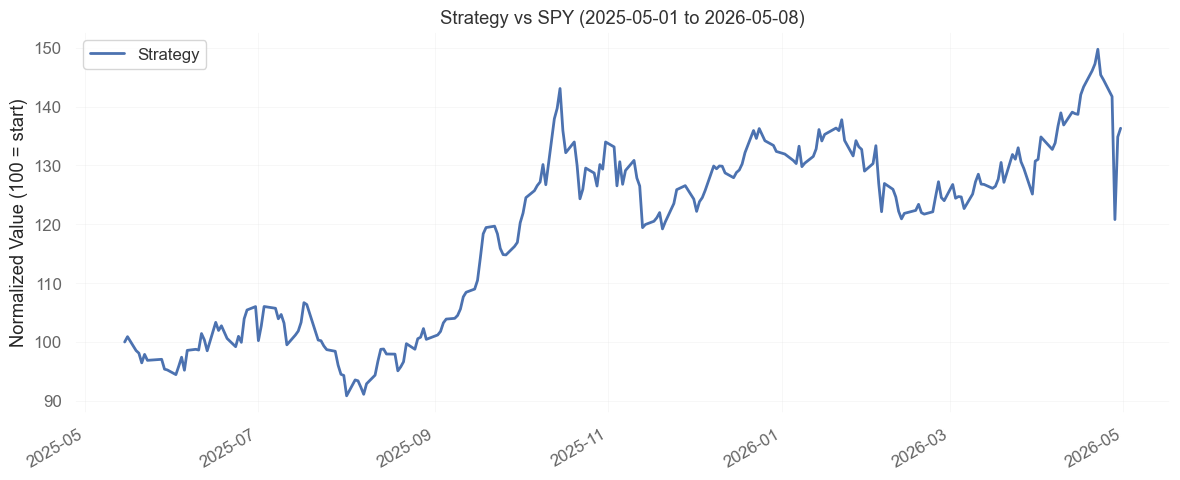

In [42]:
# Plot equity curve vs SPY
import matplotlib.pyplot as plt

if len(equity_best) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    # Normalize to 100
    equity_norm = equity_best / equity_best.iloc[0] * 100
    equity_norm.plot(ax=ax, label='Strategy', linewidth=2)
    
    # Add SPY benchmark if available
    spy = scores_df[scores_df['ticker'] == 'SPY'][['date', 'close']].drop_duplicates()
    spy = spy[(spy['date'] >= cfg_best.start_date) & (spy['date'] <= cfg_best.end_date)]
    if len(spy) > 0:
        spy = spy.set_index('date')['close']
        spy_norm = spy / spy.iloc[0] * 100
        spy_norm.plot(ax=ax, label='SPY', linewidth=1, alpha=0.7)
    
    ax.set_title(f'Strategy vs SPY ({cfg_best.start_date} to {cfg_best.end_date})')
    ax.set_ylabel('Normalized Value (100 = start)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
